 # Trabalho Computacional 3 - Reconhecimento de Padrões

 ## Classificadores Gaussianos, DMP e Análise de Componentes Principais (PCA)

 **Aluno:** Lucas José Lemos Braz

 **Disciplina:** Reconhecimento de Padrões (Pós-Graduação)

 ### 1. Configurações e Importações

 Importação das bibliotecas científicas e configuração do ambiente de visualização.

In [1]:
import sys
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do Scikit-Learn para validação e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Adicionando o diretório raiz ao path para importar os modelos customizados
sys.path.append(os.path.abspath("../../.."))

# IMPORTANTE: Assume-se que este arquivo contém as implementações corrigidas
# (DMP com seleção de K via DB/CH/Dunn e CQG com regularização/SVD)
from classificao_padroes.models_trabalho3 import (
    analizar_invertibilidade,
    PCA,
    ClassificadorDMP,
    ClassificadorQuadraticoGaussiano
)

# Configurações de plotagem
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)


2026-02-21 16:20:11.937 | INFO     | classificao_padroes.config:<module>:11 - PROJ_ROOT path is: /home/apo-pc/Documents/Github/Trabalhos_Rec_Padroes


 ### 2. Carregamento e Pré-processamento dos Dados

 O dataset *Wall-Following Robot* possui 24 sensores de ultrassom dispostos circularmente.

 Os dados são carregados e normalizados (Z-score) para garantir estabilidade numérica, especialmente para o DMP (baseado em distância Euclidiana).

Dataset Carregado: (5456, 24)
Classes: ['Move-Forward' 'Sharp-Right-Turn' 'Slight-Left-Turn' 'Slight-Right-Turn']


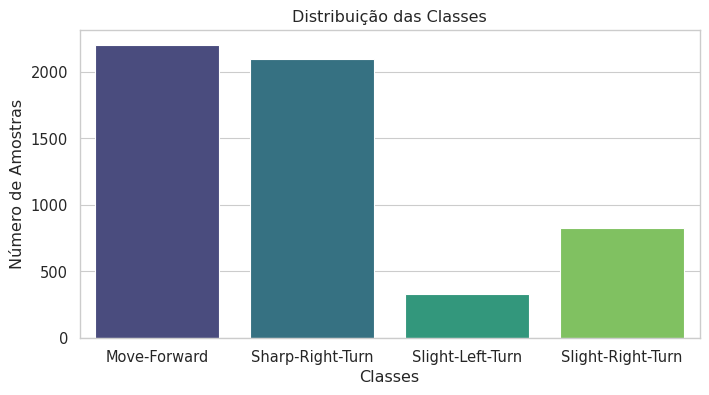

In [ ]:
# Caminhos e carregamento
data_path_24 = "../../data/interin/wall+following+robot+navigation+data/sensor_readings_24.data"
col_names_24 = [f"US{i + 1}" for i in range(24)] + ["Class"]

data_df = pd.read_csv(data_path_24, names=col_names_24)

# Separação de Atributos e Classes
X_raw = data_df.drop("Class", axis=1).values
y_labels = data_df["Class"].values

# Codificação das classes (String -> Inteiro) para facilitar métricas
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
classes_nomes = le.classes_

y

# Normalização Z-Score (Média 0, Desvio 1)
# Crítico para classificadores baseados em distância (DMP) e covariância (CQG)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset Carregado: {X_scaled.shape}")
print(f"Classes: {classes_nomes}")

# Verificação de Balanceamento
plt.figure(figsize=(8, 4))
sns.countplot(x=y_labels, palette='viridis', order=classes_nomes)
plt.title("Distribuição das Classes")
plt.xlabel("Classes")
plt.ylabel("Número de Amostras")
plt.show()


 ### 3. Funções Auxiliares de Avaliação Estatística

 Como exigido em trabalhos de pós-graduação, não avaliamos o modelo em apenas uma rodada.

 Esta função executa **Nr=100 rodadas** de Monte Carlo (divisões aleatórias de treino/teste) para gerar estatísticas robustas (Média e Desvio Padrão).

In [3]:
def executar_experimento_monte_carlo(X, y, classificador_class, params={}, n_runs=20, test_size=0.3):
    """
    Executa N rodadas de treino e teste e coleta métricas globais e por classe.
    """
    print(f"Iniciando {n_runs} rodadas para {classificador_class.__name__}...")

    global_accuracies = []
    class_accuracies = {c: [] for c in np.unique(y)}
    times_train = []
    times_test = []

    for i in range(n_runs):
        # Divisão aleatória
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

        # Instanciação e Treino
        clf = classificador_class(**params)

        start_train = time.time()
        clf.fit(X_train, y_train)
        times_train.append(time.time() - start_train)

        # Teste
        start_test = time.time()
        y_pred = clf.predict(X_test)
        times_test.append(time.time() - start_test)

        # Métricas Globais
        global_accuracies.append(accuracy_score(y_test, y_pred))

        # Métricas por Classe (Recall/Acurácia por classe)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        for cls_label in np.unique(y):
            # O report usa strings dos labels se y for string, ou str(int) se y for int
            cls_key = str(cls_label)
            if cls_key in report:
                class_accuracies[cls_label].append(report[cls_key]['recall'])
            else:
                class_accuracies[cls_label].append(0.0)

    # Compilação dos Resultados
    results = {
        'Modelo': classificador_class.__name__,
        'Global_Mean': np.mean(global_accuracies),
        'Global_Std': np.std(global_accuracies),
        'Time_Train_Mean': np.mean(times_train),
        'Time_Test_Mean': np.mean(times_test)
    }

    # Adiciona média e desvio por classe
    for cls_label in np.unique(y):
        results[f'Class_{cls_label}_Mean'] = np.mean(class_accuracies[cls_label])
        results[f'Class_{cls_label}_Std'] = np.std(class_accuracies[cls_label])

    return results, global_accuracies


def formatar_tabela_latex(df_results, class_names):
    """Gera uma visualização amigável similar à tabela solicitada no PDF."""
    display_df = pd.DataFrame()
    display_df['Classificador'] = df_results['Modelo']

    # Formata Global
    display_df['Global'] = df_results.apply(lambda row: f"{row['Global_Mean']:.4f} ± {row['Global_Std']:.4f}", axis=1)

    # Formata por Classe
    for i, name in enumerate(class_names):
        display_df[f'{name}'] = df_results.apply(
            lambda row: f"{row[f'Class_{i}_Mean']:.4f} ± {row[f'Class_{i}_Std']:.4f}", axis=1
        )

    return display_df


 ---

 ## QUESTÃO 1: Análise sem PCA (Espaço Original 24D)



 ### 1.1 e 1.2: Análise de Invertibilidade

 Verifica-se se as matrizes de covariância são bem condicionadas para aplicação do CQG.

In [4]:
# A função analisar_invertibilidade deve ser capaz de lidar com DataFrame ou Array
# Criando DF temporário apenas para essa função, se necessário
analizar_invertibilidade(data_df, "Original 24 Sensores")


Análise de Invertibilidade: Original 24 Sensores
Global -> Posto: 24, Cond: 2.05e+01, RCond: 4.87e-02
Classe Move-Forward -> Posto: 24, Cond: 5.35e+01, RCond: 1.87e-02
Classe Sharp-Right-Turn -> Posto: 24, Cond: 3.13e+01, RCond: 3.20e-02
Classe Slight-Left-Turn -> Posto: 24, Cond: 1.73e+02, RCond: 5.77e-03
Classe Slight-Right-Turn -> Posto: 24, Cond: 1.96e+02, RCond: 5.10e-03
--------------------------------------------------


 ### 1.3: Experimento Comparativo (DMP vs CQG)

 Execução de 100 rodadas para preenchimento da tabela de desempenho.



 *Nota:* Para o DMP, definimos `k_max` baseado na heurística $\sqrt{N_{min}}$, para evitar overfitting (transformar o DMP em 1-NN).

Heurística para DMP: k_max definido como 18 (aprox sqrt(328))
Iniciando 20 rodadas para ClassificadorDMP...
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=18, CH=2, Dunn=14, Sil=18, I=3, BH=18] -> Frequências: [k=18(3x), k=2(1x), k=14(1x), k=3(1x)] -> K ótimo: 18
  Classe 1: Votos [DB=16, CH=2, Dunn=9, Sil=18, I=3, BH=18] -> Frequências: [k=18(2x), k=16(1x), k=2(1x), k=9(1x), k=3(1x)] -> K ótimo: 18
  Classe 2: Votos [DB=18, CH=2, Dunn=11, Sil=18, I=2, BH=18] -> Frequências: [k=18(3x), k=2(2x), k=11(1x)] -> K ótimo: 18
  Classe 3: Votos [DB=6, CH=3, Dunn=16, Sil=2, I=2, BH=18] -> Frequências: [k=2(2x), k=6(1x), k=3(1x), k=16(1x), k=18(1x)] -> K ótimo: 2
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=17, CH=2, Dunn=13, Sil=16, I=3, BH=18] -> Frequências: [k=17(1x), k=2(1x), k=13(1x), k=16(1x), k=3(1x), k=18(1x)] -> K ótimo: 17
  Classe 1: Votos [DB=17, CH=2, Dunn=11, Sil=14, I=3, BH=18] -> Frequências: [k=17(1x), k=2(1x), k=11(1x), k=14(

,Classificador,Global,Move-Forward,Sharp-Right-Turn,Slight-Left-Turn,Slight-Right-Turn
0,ClassificadorQuadraticoGaussiano,0.6792 ± 0.0107,0.6308 ± 0.0194,0.6239 ± 0.0196,0.8840 ± 0.0253,0.8652 ± 0.0170
1,ClassificadorDMP,0.6892 ± 0.0321,0.7626 ± 0.0701,0.7659 ± 0.1268,0.8041 ± 0.1206,0.2545 ± 0.2145


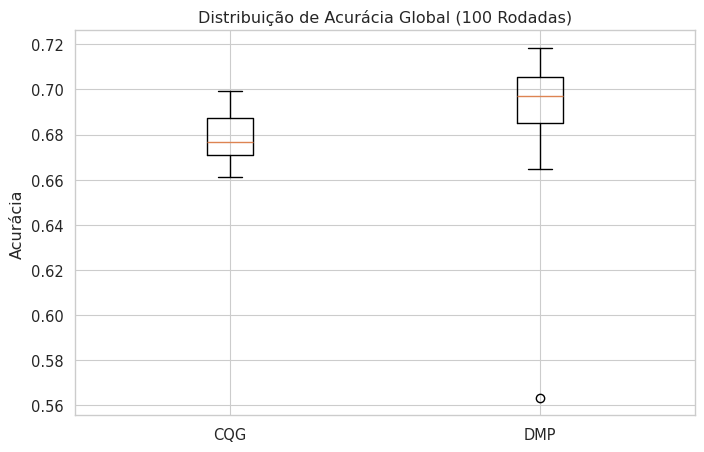

In [5]:
# Configuração do DMP
N_min = data_df["Class"].value_counts().min()
k_max_heuristic = int(np.sqrt(N_min))
print(f"Heurística para DMP: k_max definido como {k_max_heuristic} (aprox sqrt({N_min}))")

# Parâmetros dos Modelos
params_dmp = {'k_min': 2, 'k_max': k_max_heuristic, 'n_runs': 10}  # n_runs interno do k-means
params_cqg = {}  # CQG padrão

# Execução (Pode levar alguns minutos devido às 100 rodadas)
res_dmp, acc_dmp = executar_experimento_monte_carlo(X_scaled, y_encoded, ClassificadorDMP, params_dmp, n_runs=20)
res_cqg, acc_cqg = executar_experimento_monte_carlo(X_scaled, y_encoded, ClassificadorQuadraticoGaussiano, params_cqg, n_runs=20)

# Consolidação
df_q1 = pd.DataFrame([res_cqg, res_dmp])

print("\n--- Tabela de Resultados (Questão 1.3) ---")
tabela_q1 = formatar_tabela_latex(df_q1, classes_nomes)
display(tabela_q1)

# Boxplot para comparação visual da estabilidade
plt.figure(figsize=(8, 5))
plt.boxplot([acc_cqg, acc_dmp], labels=['CQG', 'DMP'])
plt.title("Distribuição de Acurácia Global (100 Rodadas)")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()


 ---

 ## QUESTÃO 2: Aplicação de PCA



 ### 2.1: Determinação do número de componentes (q)

 Analisamos o espectro de autovalores para escolher um `q` que reduza a dimensionalidade retendo pelo menos 95% da informação (variância).

Componentes necessários para 90% de variância: q = 18
Componentes necessários para 95% de variância: q = 21
Componentes necessários para 99% de variância: q = 24


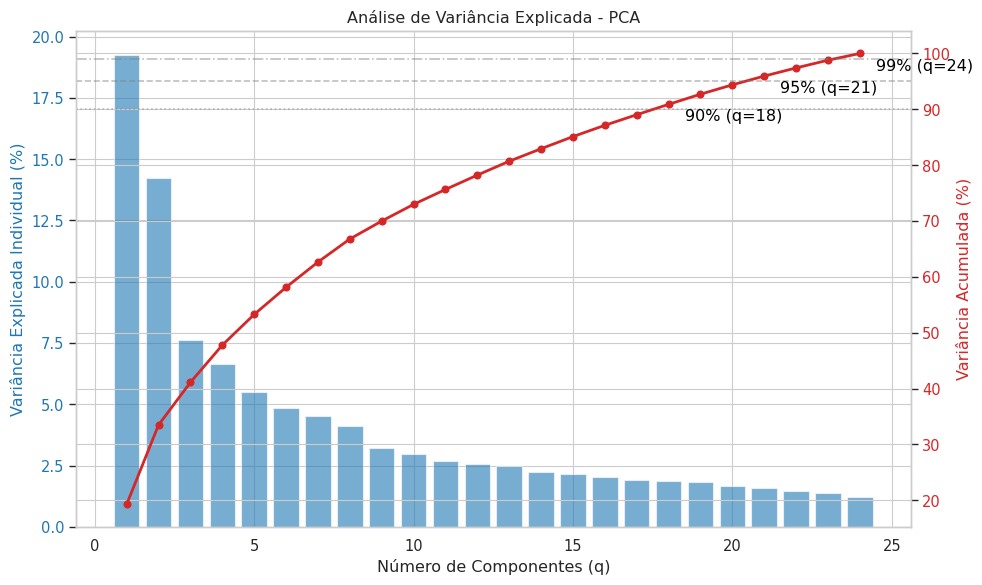


---> Valor de q escolhido para a Questão 2.2: 21 componentes.


In [6]:
# Ajuste do PCA na base completa (apenas para análise de variância)
pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

# Cálculo das variâncias
var_ratio = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_ratio)

# Plotagem Profissional (Scree Plot + Acumulada)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Componentes (q)')
ax1.set_ylabel('Variância Explicada Individual (%)', color=color)
ax1.bar(range(1, len(var_ratio) + 1), var_ratio * 100, color=color, alpha=0.6, label='Individual')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Segundo eixo y
color = 'tab:red'
ax2.set_ylabel('Variância Acumulada (%)', color=color)
ax2.plot(range(1, len(var_cum)+1), var_cum * 100, color=color, marker='o', linewidth=2, label='Acumulada')
ax2.tick_params(axis='y', labelcolor=color)

# Linhas de corte (90%, 95%, 99%)
for threshold, style in zip([0.90, 0.95, 0.99], [':', '--', '-.']):
    q_idx = np.argmax(var_cum >= threshold) + 1
    ax2.axhline(y=threshold * 100, color='gray', linestyle=style, alpha=0.5)
    ax2.text(q_idx + 0.5, threshold * 100 - 2, f'{threshold * 100:.0f}% (q={q_idx})', color='black')
    print(f"Componentes necessários para {threshold * 100:.0f}% de variância: q = {q_idx}")

plt.title("Análise de Variância Explicada - PCA")
fig.tight_layout()
plt.show()

# Definição do q escolhido (Critério > 95%)
q_selected = np.argmax(var_cum >= 0.95) + 1
print(f"\n---> Valor de q escolhido para a Questão 2.2: {q_selected} componentes.")


 ### 2.2: Experimento Comparativo com PCA

 Transformação dos dados para `q` dimensões e repetição das 100 rodadas de teste.



 **Hipótese:** Espera-se que o desempenho se mantenha próximo ao original, mas com menor custo computacional no CQG (inversão de matrizes menores) e possivelmente melhor generalização no DMP (remoção de ruído).

Redução de Dimensionalidade: (5456, 24) -> (5456, 21)
Iniciando 20 rodadas para ClassificadorDMP...
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=18, CH=2, Dunn=10, Sil=13, I=3, BH=18] -> Frequências: [k=18(2x), k=2(1x), k=10(1x), k=13(1x), k=3(1x)] -> K ótimo: 18
  Classe 1: Votos [DB=16, CH=2, Dunn=4, Sil=16, I=3, BH=18] -> Frequências: [k=16(2x), k=2(1x), k=4(1x), k=3(1x), k=18(1x)] -> K ótimo: 16
  Classe 2: Votos [DB=15, CH=2, Dunn=17, Sil=14, I=2, BH=18] -> Frequências: [k=2(2x), k=15(1x), k=17(1x), k=14(1x), k=18(1x)] -> K ótimo: 2
  Classe 3: Votos [DB=16, CH=3, Dunn=9, Sil=2, I=2, BH=18] -> Frequências: [k=2(2x), k=16(1x), k=3(1x), k=9(1x), k=18(1x)] -> K ótimo: 2
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=17, CH=2, Dunn=10, Sil=15, I=3, BH=18] -> Frequências: [k=17(1x), k=2(1x), k=10(1x), k=15(1x), k=3(1x), k=18(1x)] -> K ótimo: 17
  Classe 1: Votos [DB=18, CH=2, Dunn=15, Sil=18, I=3, BH=18] -> Frequências: [k=18(3x), k=2

,Classificador,Global,Move-Forward,Sharp-Right-Turn,Slight-Left-Turn,Slight-Right-Turn
0,ClassificadorQuadraticoGaussiano (PCA),0.6801 ± 0.0119,0.6274 ± 0.0215,0.6318 ± 0.0158,0.8841 ± 0.0257,0.8598 ± 0.0216
1,ClassificadorDMP (PCA),0.6877 ± 0.0550,0.6574 ± 0.1833,0.8010 ± 0.0554,0.7972 ± 0.1302,0.4359 ± 0.3194


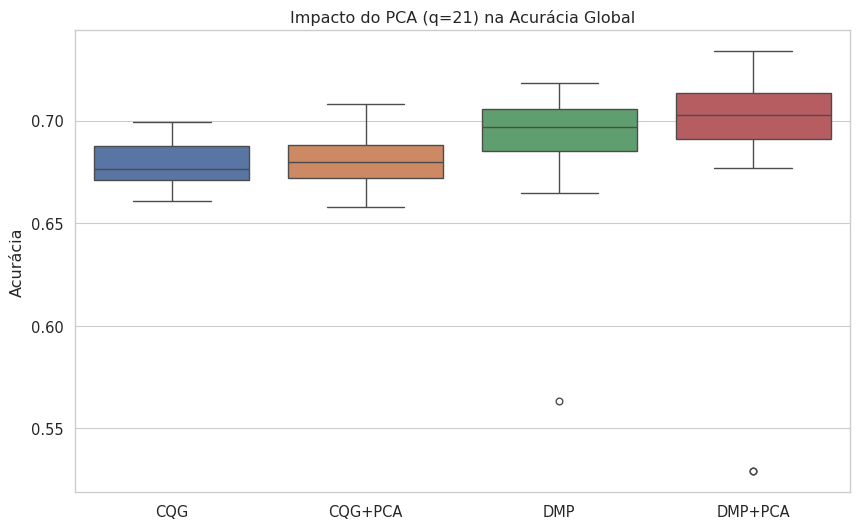

In [7]:
# Transformação dos dados
pca_final = PCA(n_components=q_selected)
pca_final.fit(X_scaled)
X_pca = pca_final.transform(X_scaled)

print(f"Redução de Dimensionalidade: {X_scaled.shape} -> {X_pca.shape}")

# Execução do Experimento no Espaço Reduzido
res_dmp_pca, acc_dmp_pca = executar_experimento_monte_carlo(X_pca, y_encoded, ClassificadorDMP, params_dmp, n_runs=20)
res_cqg_pca, acc_cqg_pca = executar_experimento_monte_carlo(X_pca, y_encoded, ClassificadorQuadraticoGaussiano, params_cqg, n_runs=20)

# Consolidação
df_q2 = pd.DataFrame([res_cqg_pca, res_dmp_pca])
df_q2['Modelo'] = df_q2['Modelo'] + " (PCA)"

print("\n--- Tabela de Resultados (Questão 2.2 - Com PCA) ---")
tabela_q2 = formatar_tabela_latex(df_q2, classes_nomes)
display(tabela_q2)

# Comparação: Com PCA vs Sem PCA
plt.figure(figsize=(10, 6))
data_boxplot = [acc_cqg, acc_cqg_pca, acc_dmp, acc_dmp_pca]
labels_boxplot = ['CQG', 'CQG+PCA', 'DMP', 'DMP+PCA']
sns.boxplot(data=data_boxplot)
plt.xticks(range(4), labels_boxplot)
plt.title(f"Impacto do PCA (q={q_selected}) na Acurácia Global")
plt.ylabel("Acurácia")
plt.show()


 ### Visualização Extra: Superfícies de Decisão (2D)

 Para fins didáticos, projetamos os dados nas 2 primeiras componentes principais e treinamos os modelos **apenas nestas 2 dimensões** para visualizar as regiões de decisão.

 *Nota: A performance aqui será inferior à de 24D ou qD, pois estamos usando apenas 2 dimensões.*

Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=4, CH=4, Dunn=15, Sil=4, I=4, BH=15] -> Frequências: [k=4(4x), k=15(2x)] -> K ótimo: 4
  Classe 1: Votos [DB=4, CH=10, Dunn=8, Sil=4, I=3, BH=15] -> Frequências: [k=4(2x), k=10(1x), k=8(1x), k=3(1x), k=15(1x)] -> K ótimo: 4
  Classe 2: Votos [DB=2, CH=2, Dunn=3, Sil=2, I=3, BH=15] -> Frequências: [k=2(3x), k=3(2x), k=15(1x)] -> K ótimo: 2
  Classe 3: Votos [DB=3, CH=10, Dunn=3, Sil=2, I=3, BH=15] -> Frequências: [k=3(3x), k=10(1x), k=2(1x), k=15(1x)] -> K ótimo: 3


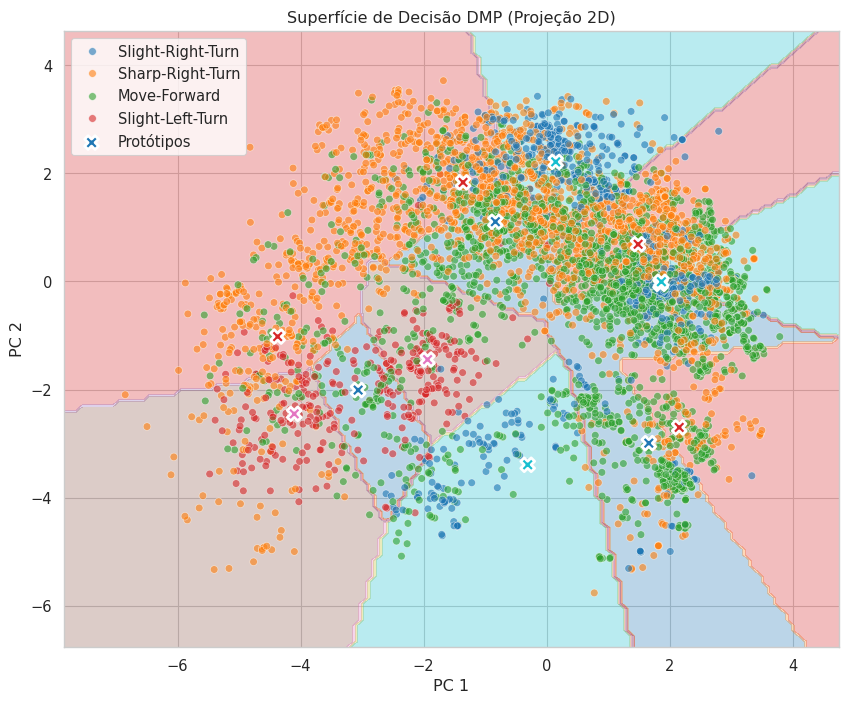

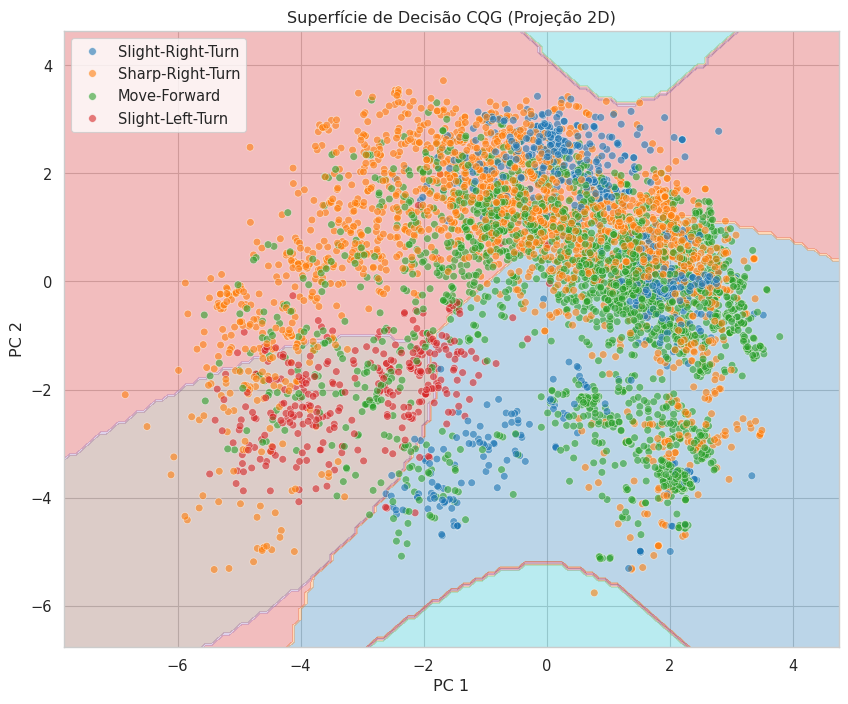

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_decision_boundary(X, y, model, title, le):
    # Treina modelo em 2D
    model.fit(X, y)

    # Meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predição no Grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    
    # Atualizado para as versões mais recentes do Matplotlib
    try:
        cmap = plt.cm.get_cmap('tab10')
    except AttributeError:
        import matplotlib as mpl
        cmap = mpl.colormaps['tab10']

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    
    # ---------------------------------------------------------
    # FIX: Converte os números de volta para os nomes das classes
    # ---------------------------------------------------------
    y_class_names = le.inverse_transform(y)
    
    # Passamos 'y_class_names' para o hue em vez de 'y'
    sns.scatterplot(
        x=X[:, 0], 
        y=X[:, 1], 
        hue=y_class_names, 
        palette='tab10', 
        legend='full', 
        s=30, 
        alpha=0.6
    )

    # Se for DMP, plotar protótipos
    if hasattr(model, 'all_prototypes_') and len(model.all_prototypes_) > 0:
        prototypes = model.all_prototypes_
        prototype_labels = model.all_labels_
        
        # Opcional: decodificar os labels dos protótipos se quiser usá-los no hover ou logs
        prototype_labels_str = le.inverse_transform(prototype_labels)
        
        # Normalize integer indices for colormap (0 to num_classes-1)
        # Prevenindo erro de divisão por zero caso haja apenas a classe 0
        max_label = np.max(prototype_labels) if np.max(prototype_labels) > 0 else 1
        colors = cmap(prototype_labels / max_label)
        
        plt.scatter(prototypes[:, 0], prototypes[:, 1], 
                    c=colors, marker='X', s=100, label='Protótipos', edgecolors='white', linewidths=2)

    plt.title(title)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend()
    plt.show()

# --- Execução ---

# Preparação 2D
pca_2d = PCA(n_components=2)
pca_2d.fit(X_scaled)
X_2d = pca_2d.transform(X_scaled)

# Assumindo que 'le' é o seu LabelEncoder instanciado e "fitado" anteriormente
# ex: le = LabelEncoder()
# ex: y_encoded = le.fit_transform(y_strings)

# Visualização DMP 2D (Adicionando o argumento le=le)
dmp_2d = ClassificadorDMP(k_min=2, k_max=15, n_runs=10)
plot_decision_boundary(X_2d, y_encoded, dmp_2d, "Superfície de Decisão DMP (Projeção 2D)", le=le)

# Visualização CQG 2D (Adicionando o argumento le=le)
cqg_2d = ClassificadorQuadraticoGaussiano()
plot_decision_boundary(X_2d, y_encoded, cqg_2d, "Superfície de Decisão CQG (Projeção 2D)", le=le)

In [16]:
dmp_2d.all_labels_
le.inverse_transform(dmp_2d.all_labels_)

array(['Move-Forward', 'Move-Forward', 'Move-Forward', 'Move-Forward',
       'Sharp-Right-Turn', 'Sharp-Right-Turn', 'Sharp-Right-Turn',
       'Sharp-Right-Turn', 'Slight-Left-Turn', 'Slight-Left-Turn',
       'Slight-Right-Turn', 'Slight-Right-Turn', 'Slight-Right-Turn'],
      dtype=object)